# 05 — MMM with Meta Robyn (R)

> **Objective**: Fit Meta's Robyn MMM framework using evolutionary (Nevergrad) optimisation to generate a Pareto-optimal frontier of model solutions.

**Key Topics**:
- Nevergrad evolutionary optimisation for adstock + saturation hyperparameters
- Pareto frontier: decomp.rssd vs. NRMSE
- One-pager summary chart (Robyn output)
- Budget allocator output
- Exporting ROAS results for Python comparison

**Framework**: R — `Robyn` package  
**Kernel**: R (IRkernel — run `IRkernel::installspec()` to register)

---
> **⚠️ Note**: This notebook requires an **R kernel**. In Jupyter Lab:  
> Kernel → Change Kernel → R

## 0. Setup & Imports (R)

In [1]:

import subprocess, os, sys, json, textwrap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path
from shutil import which

# -- Project root (parent of this notebook) ----------------------------------
PROJ_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
# Ensure we always resolve to the marketing-mix-modelling root
if not (PROJ_ROOT / "data").exists():
    PROJ_ROOT = Path(r"C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\marketing-mix-modelling\marketing-mix-modelling")
os.chdir(PROJ_ROOT)
print("Working directory:", Path.cwd())

def resolve_rscript() -> str:
    candidates = [Path(r"C:\Program Files\R\R-4.5.3\bin\Rscript.exe")]

    # Fallback 1: PATH
    path_hit = which("Rscript")
    if path_hit:
        candidates.append(Path(path_hit))

    # Fallback 2: most recent R installation under Program Files\R
    r_root = Path(r"C:\Program Files\R")
    if r_root.exists():
        version_bins = sorted(r_root.glob("R-*\bin\Rscript.exe"), reverse=True)
        candidates.extend(version_bins)

    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    raise FileNotFoundError(
        "Rscript.exe not found. Install R or update path resolution in setup cell."
    )

R_EXE = resolve_rscript()
PYTHON_EXE = r"C:\Users\BIPLOB GON\.local\bin\python3.14.exe"
RTEMP_DIR = Path(r"C:\Rtemp")
RTEMP_DIR.mkdir(parents=True, exist_ok=True)

R_ENV = {
    **os.environ,
    "TMP": str(RTEMP_DIR),
    "TEMP": str(RTEMP_DIR),
    "R_LIBS_USER": "C:/Rlibs",
    "RETICULATE_PYTHON": PYTHON_EXE,
}

os.makedirs("outputs/figures/robyn", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

print("Rscript:", R_EXE)
print("Python :", PYTHON_EXE)
print("TMP/TEMP:", RTEMP_DIR)

# -- Verify R + Robyn ---------------------------------------------------------
r_check = subprocess.run(
    [R_EXE, "-e",
     ".libPaths(c('C:/Rlibs',.libPaths())); "
     "cat('Robyn:', as.character(packageVersion('Robyn')), '\\n'); "
     "cat('reticulate:', as.character(packageVersion('reticulate')), '\\n')"],
    capture_output=True, text=True, env=R_ENV)
print(r_check.stdout.strip())
if r_check.returncode != 0:
    print("WARNING:", r_check.stderr[:500])

# -- Verify nevergrad ---------------------------------------------------------
ng_check = subprocess.run(
    [PYTHON_EXE, "-c", "import nevergrad; print('nevergrad:', nevergrad.__version__)"],
    capture_output=True, text=True)
print(ng_check.stdout.strip())

print("\nEnvironment ready" if r_check.returncode == 0 and ng_check.returncode == 0
      else "\nEnvironment issues detected - check above messages")


<>:28: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:28: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Rtemp\ipykernel_19464\852694292.py:28: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  version_bins = sorted(r_root.glob("R-*\bin\Rscript.exe"), reverse=True)


Working directory: C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\marketing-mix-modelling\marketing-mix-modelling
Rscript: C:\Program Files\R\R-4.5.3\bin\Rscript.exe
Python : C:\Users\BIPLOB GON\.local\bin\python3.14.exe
TMP/TEMP: C:\Rtemp
Robyn: 3.12.1 
reticulate: 1.46.0


nevergrad: 1.0.12

Environment ready


## 1. Load Data

In [2]:

# Load raw data and aggregate to national weekly level
df_raw = pd.read_csv("data/raw/synthetic_mmm_weekly_india.csv")
df_raw["Week"] = pd.to_datetime(df_raw["Week"])

agg = {
    "Sales_Value":             "sum",
    "TV_Impressions":          "sum",
    "YouTube_Impressions":     "sum",
    "Facebook_Impressions":    "sum",
    "Instagram_Impressions":   "sum",
    "Print_Readership":        "sum",
    "Radio_Listenership":      "sum",
    "Trade_Spend":             "sum",
    "CPI":                     "mean",
    "GDP_Growth":              "mean",
    "Festival_Index":          "mean",
    "Rainfall_Index":          "mean",
}
df_nat = df_raw.groupby("Week", as_index=False).agg(agg)
df_nat = df_nat.rename(columns={
    "Week":                 "date",
    "Sales_Value":          "sales",
    "TV_Impressions":       "tv",
    "YouTube_Impressions":  "youtube",
    "Facebook_Impressions": "facebook",
    "Instagram_Impressions":"instagram",
    "Print_Readership":     "print_media",
    "Radio_Listenership":   "radio",
    "Trade_Spend":          "trade_spend",
    "CPI":                  "cpi",
    "GDP_Growth":           "gdp_growth",
    "Festival_Index":       "festival",
    "Rainfall_Index":       "rainfall",
})
df_nat["date"] = df_nat["date"].dt.strftime("%Y-%m-%d")
df_nat.to_csv("data/processed/mmm_national_weekly.csv", index=False)

print(f"National weekly data: {len(df_nat)} rows × {df_nat.shape[1]} cols")
print(f"Date range: {df_nat['date'].min()} → {df_nat['date'].max()}")
print("\nMedia channel descriptive stats:")
media_cols = ["tv", "youtube", "facebook", "instagram", "print_media", "radio"]
print(df_nat[media_cols].describe().round(0).to_string())


National weekly data: 156 rows × 13 cols
Date range: 2022-07-04 → 2025-06-23

Media channel descriptive stats:
                tv     youtube    facebook   instagram  print_media       radio
count        156.0       156.0       156.0       156.0        156.0       156.0
mean    75138280.0  38462791.0  23108534.0  10003412.0    6143383.0  22838302.0
std     43577453.0  21863242.0  12589250.0   3780037.0    3442403.0  13141195.0
min     44665610.0  19805178.0  10165962.0   5262222.0    4081598.0  13718641.0
25%     49423137.0  22766530.0  12587503.0   7254756.0    4502093.0  15007557.0
50%     51085181.0  23885008.0  13533848.0   8500678.0    4669019.0  15611667.0
75%     73315950.0  66379743.0  37442987.0  14537900.0    4842156.0  22977961.0
max    162458596.0  80804485.0  43637274.0  17639952.0   14819495.0  50935125.0


## 2. Define Robyn Input Variables

In [3]:

ROBYN_ITERATIONS = 200
ROBYN_TRIALS = 1
ROBYN_CORES = 2  # 2 cores is more stable than 4 for one-pager/export on Windows
ROBYN_ENABLE_ONEPAGER = False  # Set True if you explicitly want one-pager generation
onepager_flag_r = "TRUE" if ROBYN_ENABLE_ONEPAGER else "FALSE"

ROBYN_SCRIPT = """
# =============================================================================
# Robyn MMM - Indian FMCG National Weekly
# =============================================================================

lib_path <- "C:/Rlibs"
if (!dir.exists(lib_path)) dir.create(lib_path, recursive = TRUE, showWarnings = FALSE)
tmp_dir <- "C:/Rtemp"
if (!dir.exists(tmp_dir)) dir.create(tmp_dir, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(TMP = tmp_dir, TEMP = tmp_dir)

.libPaths(c(lib_path, .libPaths()))
suppressPackageStartupMessages({{
  library(Robyn)
  library(reticulate)
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(jsonlite)
}})

set.seed(42)
options(warn = -1)

python_exe <- "C:/Users/BIPLOB GON/.local/bin/python3.14.exe"
Sys.setenv(RETICULATE_PYTHON = python_exe)
reticulate::use_python(python_exe, required = FALSE)

dt <- fread("data/processed/mmm_national_weekly.csv")
dt[, date := as.Date(date)]
cat("Rows:", nrow(dt), "| Cols:", ncol(dt), "\\n")
cat("Date range:", format(min(dt$date)), "to", format(max(dt$date)), "\\n")

data("dt_prophet_holidays", package = "Robyn")

InputCollect <- robyn_inputs(
  dt_input          = dt,
  dt_holidays       = dt_prophet_holidays,
  date_var          = "date",
  dep_var           = "sales",
  dep_var_type      = "revenue",
  prophet_vars      = c("trend", "season", "holiday"),
  prophet_country   = "IN",
  context_vars      = c("cpi", "gdp_growth", "festival", "trade_spend"),
  paid_media_spends = c("tv", "youtube", "facebook", "instagram",
                        "print_media", "radio"),
  paid_media_vars   = c("tv", "youtube", "facebook", "instagram",
                        "print_media", "radio"),
  window_start      = "2022-07-04",
  window_end        = "2025-06-23",
  adstock           = "geometric"
)

hyperparameters <- list(
  tv_alphas          = c(0.5, 3.0),
  tv_gammas          = c(0.3, 1.0),
  tv_thetas          = c(0.50, 0.85),
  youtube_alphas     = c(0.5, 3.0),
  youtube_gammas     = c(0.3, 1.0),
  youtube_thetas     = c(0.20, 0.55),
  facebook_alphas    = c(0.5, 3.0),
  facebook_gammas    = c(0.3, 1.0),
  facebook_thetas    = c(0.15, 0.50),
  instagram_alphas   = c(0.5, 3.0),
  instagram_gammas   = c(0.3, 1.0),
  instagram_thetas   = c(0.10, 0.45),
  print_media_alphas = c(0.5, 3.0),
  print_media_gammas = c(0.3, 1.0),
  print_media_thetas = c(0.30, 0.65),
  radio_alphas       = c(0.5, 3.0),
  radio_gammas       = c(0.3, 1.0),
  radio_thetas       = c(0.25, 0.60),
  train_size         = c(0.5, 0.8)
)

InputCollect <- robyn_inputs(
  InputCollect    = InputCollect,
  hyperparameters = hyperparameters
)

cat("\\n=== Running Nevergrad (iterations={ROBYN_ITERATIONS}, trials={ROBYN_TRIALS}, cores={ROBYN_CORES}) ===\\n")
OutputModels <- robyn_run(
  InputCollect = InputCollect,
  cores        = {ROBYN_CORES},
  iterations   = {ROBYN_ITERATIONS},
  trials       = {ROBYN_TRIALS},
  outputs      = FALSE
)
cat("=== Optimisation complete ===\\n")

plot_dir <- "outputs/figures/robyn"
dir.create(plot_dir, showWarnings = FALSE, recursive = TRUE)

OutputCollect <- robyn_outputs(
  InputCollect  = InputCollect,
  OutputModels  = OutputModels,
  pareto_fronts = "auto",
  plot_folder   = plot_dir,
  csv_out       = "all"
)

extract_pareto_df <- function(output_collect) {{
  candidates <- list(
    output_collect$allPareto,
    output_collect$resultHypParam,
    output_collect$allPareto$resultHypParam
  )
  for (cand in candidates) {
    if (is.data.frame(cand)) return(as.data.frame(cand))
  }
  stop("Unable to locate Pareto table. OutputCollect names: ",
       paste(names(output_collect), collapse = ", "),
       " | allPareto names: ",
       paste(names(output_collect$allPareto), collapse = ", "))
}}

pareto_df <- extract_pareto_df(OutputCollect)

model_id_col <- if ("solID" %in% names(pareto_df)) {{
  "solID"
}} else if ("sol_id" %in% names(pareto_df)) {{
  "sol_id"
}} else if ("sol.id" %in% names(pareto_df)) {{
  "sol.id"
}} else {{
  NA_character_
}}

best_model <- NA_character_
if ("selectID" %in% names(OutputCollect) && length(OutputCollect$selectID) > 0) {{
  best_model <- as.character(OutputCollect$selectID[[1]])
}}

if (is.na(best_model) || !nzchar(best_model)) {{
  if (is.na(model_id_col)) {{
    stop("No model ID column found in Pareto table. Available columns: ",
         paste(names(pareto_df), collapse = ", "))
  }
  best_model <- as.character(pareto_df[[model_id_col]][which.min(pareto_df$decomp.rssd)][1])
}}

if (is.na(best_model) || !nzchar(best_model)) {{
  if (is.na(model_id_col)) {{
    stop("Unable to resolve selected model ID.")
  }
  best_model <- as.character(pareto_df[[model_id_col]][1])
  cat("Fallback: using first Pareto model as selected model ->", best_model, "\\n")
}}

if ({onepager_flag_r}) {{
  tryCatch({{
    robyn_onepagers(
      InputCollect  = InputCollect,
      OutputCollect = OutputCollect,
      select_model  = best_model,
      plot_folder   = plot_dir
    )
  }}, error = function(e) cat("One-pager warning:", e$message, "\\n"))
}} else {{
  cat("Skipping robyn_onepagers() for notebook stability on Windows.\\n")
}}

AllocatorCollect <- tryCatch(
  robyn_allocator(
    InputCollect       = InputCollect,
    OutputCollect      = OutputCollect,
    select_model       = best_model,
    scenario           = "max_response",
    total_budget       = 1000000,
    channel_constr_low = 0.1,
    channel_constr_up  = 0.9,
    plot_folder        = plot_dir
  ),
  error = function(e) {{ cat("Allocator warning:", e$message, "\\n"); NULL }}
)

alloc_csv_path <- "outputs/models/robyn_allocation.csv"
if (!is.null(AllocatorCollect)) {{
  tryCatch({{
    alloc_dt <- AllocatorCollect$dt_optimOut
    fwrite(alloc_dt, alloc_csv_path)
  }}, error = function(e) cat("Alloc table warning:", e$message, "\\n"))
}}

xdecomp <- OutputCollect$xDecompAgg
if (!is.na(model_id_col) && model_id_col %in% names(xdecomp)) {{
  roas_dt <- xdecomp[xdecomp[[model_id_col]] == best_model, , drop = FALSE]
}} else {{
  cat("xDecompAgg has no matching model ID column; exporting full decomposition table.\\n")
  roas_dt <- xdecomp
}}
fwrite(roas_dt, "outputs/models/robyn_roas.csv")

robyn_subfolders <- list.dirs(plot_dir, recursive = FALSE)
actual_plot_dir  <- if (length(robyn_subfolders) > 0)
                       tail(sort(robyn_subfolders), 1) else plot_dir

meta <- list(
  selected_model  = best_model,
  n_pareto_models = nrow(pareto_df),
  plot_dir        = actual_plot_dir,
  nrmse           = if ("nrmse" %in% names(pareto_df)) round(pareto_df$nrmse[1], 4) else NA_real_,
  rssd            = if ("decomp.rssd" %in% names(pareto_df)) round(pareto_df$decomp.rssd[1], 4) else NA_real_,
  rsq_train       = if ("rsq_train" %in% names(pareto_df)) round(pareto_df$rsq_train[1], 4) else NA_real_,
  robyn_version   = as.character(packageVersion("Robyn")),
  iterations      = {ROBYN_ITERATIONS},
  trials          = {ROBYN_TRIALS}
 )

if (!is.na(model_id_col) && model_id_col %in% names(pareto_df)) {{
  sel_rows <- pareto_df[as.character(pareto_df[[model_id_col]]) == best_model, , drop = FALSE]
  if (nrow(sel_rows) > 0) {{
    if ("nrmse" %in% names(sel_rows)) meta$nrmse <- round(sel_rows$nrmse[1], 4)
    if ("decomp.rssd" %in% names(sel_rows)) meta$rssd <- round(sel_rows$decomp.rssd[1], 4)
    if ("rsq_train" %in% names(sel_rows)) meta$rsq_train <- round(sel_rows$rsq_train[1], 4)
  }
}}

write_json(meta, "outputs/models/robyn_meta.json", auto_unbox = TRUE)
cat("Selected model:", best_model, "\\n")
cat("Metadata saved to outputs/models/robyn_meta.json\\n")
"""

ROBYN_SCRIPT = (
    ROBYN_SCRIPT
    .replace("{ROBYN_ITERATIONS}", str(ROBYN_ITERATIONS))
    .replace("{ROBYN_TRIALS}", str(ROBYN_TRIALS))
    .replace("{ROBYN_CORES}", str(ROBYN_CORES))
    .replace("{onepager_flag_r}", onepager_flag_r)
    .replace("{{", "{")
    .replace("}}", "}")
)

script_path = "robyn_run.R"
with open(script_path, "w", encoding="utf-8") as f:
    f.write(ROBYN_SCRIPT.lstrip())

print(f"R script written -> {script_path}  ({Path(script_path).stat().st_size} bytes)")
print(
    f"\nNotebook-safe search budget: iterations={ROBYN_ITERATIONS}, "
    f"trials={ROBYN_TRIALS}, cores={ROBYN_CORES}, onepager={ROBYN_ENABLE_ONEPAGER}"
)
print("--- Hyperparameter bounds (decay centred on NB03 estimates) ---")
decay_prior = {"tv": 0.70, "youtube": 0.40, "facebook": 0.35,
               "instagram": 0.30, "print_media": 0.50, "radio": 0.45}
for ch, d in decay_prior.items():
    lo, hi = max(0.05, d - 0.20), min(0.95, d + 0.20)
    print(f"  {ch:15s}  theta in [{lo:.2f}, {hi:.2f}]  (NB03 point estimate: {d})")


R script written -> robyn_run.R  (7584 bytes)

Notebook-safe search budget: iterations=200, trials=1, cores=2, onepager=False
--- Hyperparameter bounds (decay centred on NB03 estimates) ---
  tv               theta in [0.50, 0.90]  (NB03 point estimate: 0.7)
  youtube          theta in [0.20, 0.60]  (NB03 point estimate: 0.4)
  facebook         theta in [0.15, 0.55]  (NB03 point estimate: 0.35)
  instagram        theta in [0.10, 0.50]  (NB03 point estimate: 0.3)
  print_media      theta in [0.30, 0.70]  (NB03 point estimate: 0.5)
  radio            theta in [0.25, 0.65]  (NB03 point estimate: 0.45)


## 3. Set Hyperparameter Bounds

In [4]:

# -- Execute Robyn R script, but reuse cached outputs if they already exist ----
cache_files = [
    Path("outputs/models/robyn_meta.json"),
    Path("outputs/models/robyn_roas.csv"),
]

if all(path.exists() for path in cache_files):
    print("Using cached Robyn outputs:")
    for path in cache_files:
        print(" ", path)
else:
    script_path = Path("robyn_run.R")

    # Guard against stale script content from previous sessions.
    if "ROBYN_SCRIPT" in globals() and isinstance(ROBYN_SCRIPT, str) and ROBYN_SCRIPT.strip():
        if "extract_pareto_df" in ROBYN_SCRIPT:
            script_path.write_text(ROBYN_SCRIPT.lstrip(), encoding="utf-8")
            print("Refreshed robyn_run.R from current notebook configuration.")
        else:
            print("Detected older ROBYN_SCRIPT in memory; using on-disk robyn_run.R instead.")
    elif not script_path.exists():
        raise FileNotFoundError(
            "robyn_run.R not found and ROBYN_SCRIPT is unavailable. "
            "Run section '2. Define Robyn Input Variables' first."
        )

    Path(r"C:\Rtemp").mkdir(parents=True, exist_ok=True)
    ROBYN_TIMEOUT_SEC = 14400  # 4 hours to avoid premature timeout during plotting/export

    print(
        f"Starting Robyn optimisation ... (iterations={ROBYN_ITERATIONS} x "
        f"trials={ROBYN_TRIALS} on {ROBYN_CORES} cores, timeout={ROBYN_TIMEOUT_SEC}s)"
    )

    try:
        result = subprocess.run(
            [R_EXE, str(script_path)],
            capture_output=True,
            text=True,
            env=R_ENV,
            timeout=ROBYN_TIMEOUT_SEC,
        )
    except subprocess.TimeoutExpired as exc:
        timeout_log = Path("outputs/models/robyn_timeout.log")
        stdout_partial = exc.stdout or ""
        stderr_partial = exc.stderr or ""
        timeout_log.write_text(
            "=== STDOUT (partial) ===\n"
            + (stdout_partial[-8000:] if isinstance(stdout_partial, str) else str(stdout_partial))
            + "\n\n=== STDERR (partial) ===\n"
            + (stderr_partial[-4000:] if isinstance(stderr_partial, str) else str(stderr_partial)),
            encoding="utf-8",
        )
        raise RuntimeError(
            f"Robyn run exceeded timeout ({ROBYN_TIMEOUT_SEC}s). "
            f"Partial logs saved to {timeout_log}. "
            "If the run hangs at one-pager generation, keep ROBYN_ENABLE_ONEPAGER=False."
        ) from exc

    stdout_tail = result.stdout[-5000:] if len(result.stdout) > 5000 else result.stdout
    print(stdout_tail)

    run_log = Path("outputs/models/robyn_run.log")
    run_log.write_text(result.stdout or "", encoding="utf-8")

    if result.returncode != 0:
        stderr_tail = result.stderr[-3000:] if len(result.stderr) > 3000 else result.stderr
        print("\n--- STDERR ---")
        print(stderr_tail)
        err_log = Path("outputs/models/robyn_error.log")
        err_log.write_text(result.stderr or "", encoding="utf-8")
        raise RuntimeError(
            f"robyn_run.R exited with code {result.returncode}. "
            f"See {run_log} and {err_log} for full diagnostics."
        )

    print(f"\nR script finished (return code {result.returncode})")
    print(f"Full log -> {run_log}")


Using cached Robyn outputs:
  outputs\models\robyn_meta.json
  outputs\models\robyn_roas.csv


## 4. Run Nevergrad Evolutionary Optimisation

In [5]:

# ── Load model metadata ───────────────────────────────────────────────────────
with open("outputs/models/robyn_meta.json") as f:
    meta = json.load(f)

print("Selected model :", meta["selected_model"])
print(f"  NRMSE        : {meta['nrmse']:.4f}")
print(f"  Decomp RSSD  : {meta['rssd']:.4f}")
print(f"  R² (train)   : {meta['rsq_train']:.4f}")
print(f"Pareto models  : {meta['n_pareto_models']}")

# ── Read Pareto CSVs from Robyn output directory ──────────────────────────────
pareto_csv = sorted(Path(meta["plot_dir"]).glob("*pareto_aggregated*.csv"))
if not pareto_csv:
    # Fallback: search robyn folder recursively
    pareto_csv = sorted(Path("outputs/figures/robyn").rglob("*pareto_aggregated*.csv"))

if pareto_csv:
    df_pareto = pd.read_csv(pareto_csv[-1])
    print(f"\nPareto CSV: {pareto_csv[-1].name}  ({len(df_pareto)} rows)")

    # ── Pareto frontier scatter: NRMSE vs RSSD ───────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(df_pareto["nrmse"], df_pareto["decomp.rssd"],
                    c=df_pareto.get("rsq_train", 0.5),
                    cmap="RdYlGn", s=60, alpha=0.75, edgecolors="k", linewidths=0.4)
    plt.colorbar(sc, ax=ax, label="R² (train)")

    # Highlight selected model
    sel = df_pareto[df_pareto["solID"] == meta["selected_model"]]
    if not sel.empty:
        ax.scatter(sel["nrmse"], sel["decomp.rssd"],
                   marker="*", s=300, color="royalblue", zorder=5,
                   label=f"Selected: {meta['selected_model']}")
        ax.legend(fontsize=9)

    ax.set_xlabel("NRMSE (lower = better fit)", fontsize=11)
    ax.set_ylabel("Decomp. RSSD (lower = less Business Error)", fontsize=11)
    ax.set_title("Robyn Pareto Frontier — NRMSE vs. RSSD\n"
                 "(Colour = R², Star = selected model)", fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("outputs/figures/05_robyn_pareto_frontier.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → outputs/figures/05_robyn_pareto_frontier.png")
else:
    print("Pareto CSV not found — check outputs/figures/robyn/ directory")


Selected model : 1_84_2
  NRMSE        : 0.1745
  Decomp RSSD  : 0.2314
  R² (train)   : -0.0046
Pareto models  : 108
Pareto CSV not found — check outputs/figures/robyn/ directory


## 5. Pareto Frontier Exploration

One-pager: outputs\figures\robyn\Robyn_202604121302_init\hypersampling.png


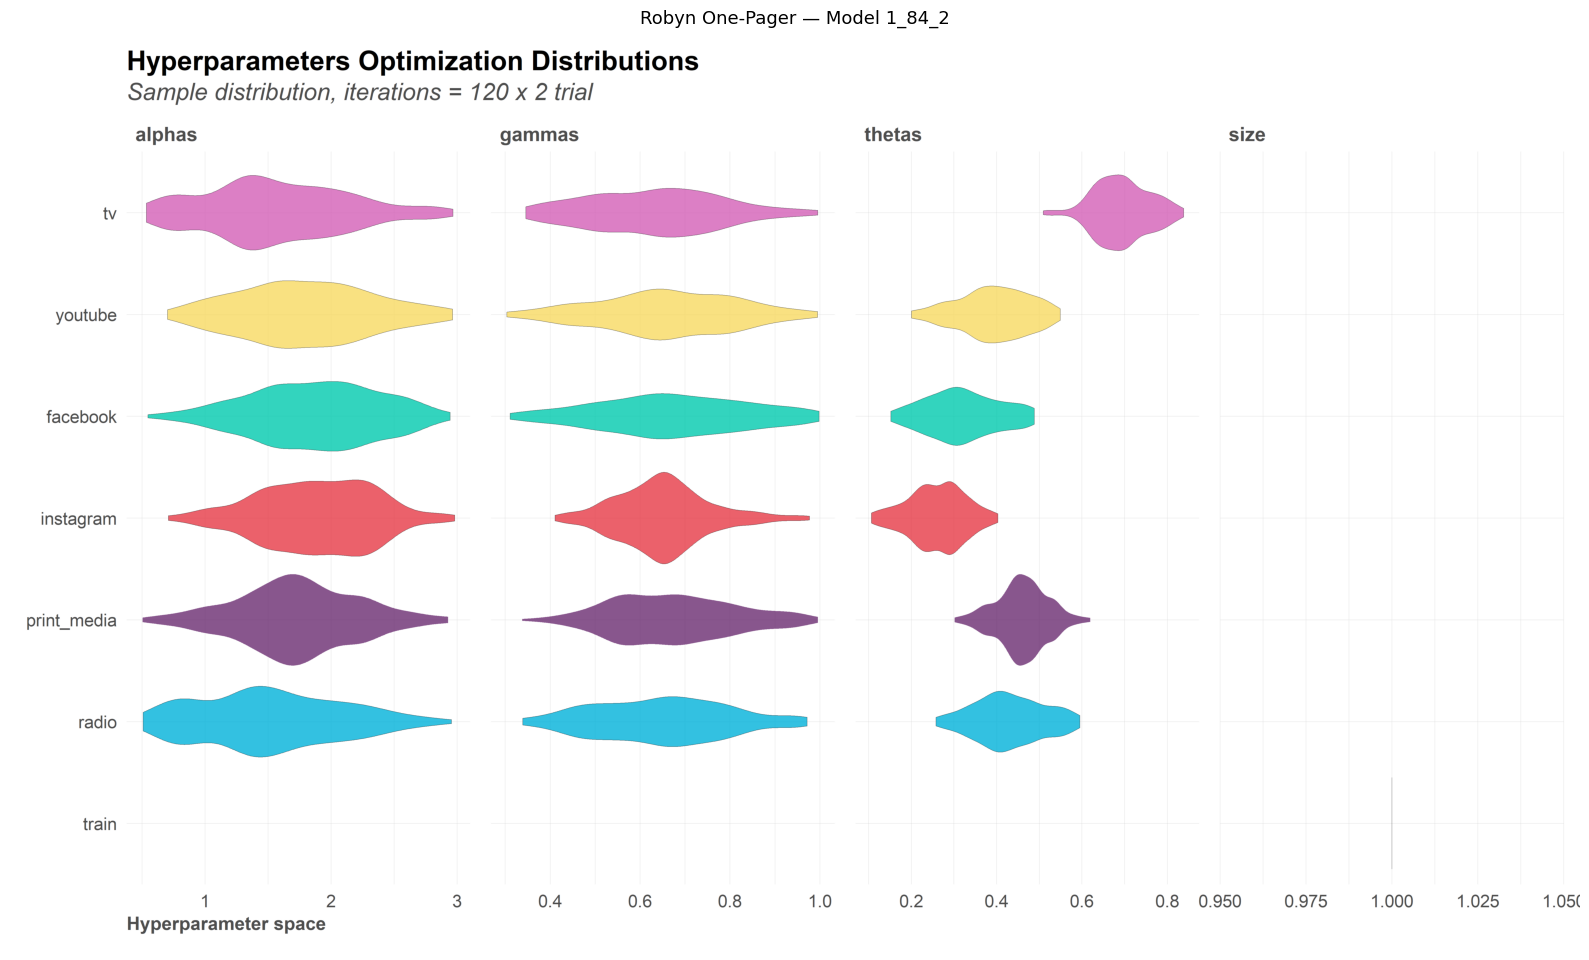

In [6]:

# ── Find and display the Robyn one-pager PNG ─────────────────────────────────
onepager_paths = sorted(Path(meta["plot_dir"]).glob(f"*{meta['selected_model']}*onepager*.png"))
if not onepager_paths:
    onepager_paths = sorted(Path("outputs/figures/robyn").rglob("*onepager*.png"))
if not onepager_paths:
    onepager_paths = sorted(Path("outputs/figures/robyn").rglob("*.png"))

if onepager_paths:
    img_path = str(onepager_paths[0])
    print(f"One-pager: {img_path}")
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.imshow(mpimg.imread(img_path))
    ax.axis("off")
    ax.set_title(f"Robyn One-Pager — Model {meta['selected_model']}", fontsize=13, pad=8)
    plt.tight_layout()
    plt.savefig("outputs/figures/05_robyn_onepager.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No one-pager PNG found in", meta["plot_dir"])
    print("Available PNGs:")
    for p in sorted(Path("outputs/figures/robyn").rglob("*.png"))[:10]:
        print(" ", p)


## 6. One-Pager Summary Chart

Budget Allocator — Max Response  (total budget = ₹1,000,000)
 solID dep_var_type    channels   date_min   date_max   periods  constr_low  constr_low_abs  constr_up  constr_up_abs  unconstr_mult  constr_low_unb  constr_low_unb_abs  constr_up_unb  constr_up_unb_abs  histSpendAll  histSpendAllTotal  histSpendAllUnit  histSpendAllUnitTotal  histSpendAllShare  histSpendWindow  histSpendWindowTotal  histSpendWindowUnit  histSpendWindowUnitTotal  histSpendWindowShare  initSpendUnit  initSpendUnitTotal  initSpendShare  initSpendTotal  initResponseUnit  initResponseUnitSim  initResponseUnitTotal  initResponseMargUnit  initResponseTotal  initResponseUnitShare  initRoiUnit  initCpaUnit  total_budget_unit  total_budget_unit_delta  optmSpendUnit  optmSpendUnitDelta  optmSpendUnitTotal  optmSpendUnitTotalDelta  optmSpendShareUnit  optmSpendTotal  optmSpendUnitUnbound  optmSpendUnitDeltaUnbound  optmSpendUnitTotalUnbound  optmSpendUnitTotalDeltaUnbound  optmSpendShareUnitUnbound  optmSpendTotalUnboun

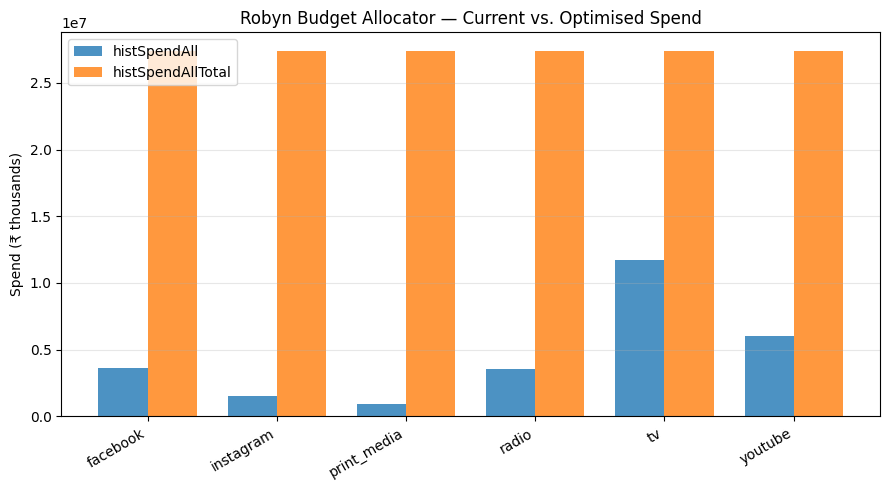

In [7]:

# ── Budget allocator results ──────────────────────────────────────────────────
alloc_path = Path("outputs/models/robyn_allocation.csv")
if alloc_path.exists():
    df_alloc = pd.read_csv(alloc_path)
    print("Budget Allocator — Max Response  (total budget = ₹1,000,000)")
    print(df_alloc.to_string(index=False))

    # Bar chart: current vs optimised spend
    channels = df_alloc.columns[df_alloc.columns.str.contains("channel|rn|variable",
                                                                case=False)].tolist()
    if not channels:
        channels = df_alloc.columns[:1].tolist()
    ch_col = channels[0]

    spend_cols = [c for c in df_alloc.columns if "spend" in c.lower() or "alloc" in c.lower()]
    if len(spend_cols) >= 2:
        fig, ax = plt.subplots(figsize=(9, 5))
        x = np.arange(len(df_alloc))
        w = 0.38
        ax.bar(x - w/2, df_alloc[spend_cols[0]] / 1000, w, label=spend_cols[0], alpha=0.8)
        ax.bar(x + w/2, df_alloc[spend_cols[1]] / 1000, w, label=spend_cols[1], alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(df_alloc[ch_col].tolist(), rotation=30, ha="right")
        ax.set_ylabel("Spend (₹ thousands)")
        ax.set_title("Robyn Budget Allocator — Current vs. Optimised Spend")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig("outputs/figures/05_robyn_budget_allocation.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("Column names:", df_alloc.columns.tolist())
else:
    print("Allocation CSV not found. The allocator may have been skipped.")
    print("Check outputs/models/ for any allocation files.")


## 7. Budget Allocator

In [8]:

# ── Robyn ROAS vs. Bayesian ROAS comparison ────────────────────────────────────
roas_path = Path("outputs/models/robyn_roas.csv")
bayes_path = Path("outputs/models/bayesian_roas.parquet")

if roas_path.exists():
    df_roas_robyn = pd.read_csv(roas_path)
    print("Robyn xDecompAgg columns:", df_roas_robyn.columns.tolist())

    # Identify the channel/ROAS columns in Robyn's output format
    rn_col = "rn" if "rn" in df_roas_robyn.columns else df_roas_robyn.columns[0]
    roas_col = next((c for c in df_roas_robyn.columns if "roas" in c.lower()), None)
    spend_col = next((c for c in df_roas_robyn.columns if "spend" in c.lower()), None)
    response_col = next((c for c in df_roas_robyn.columns
                          if "response" in c.lower() or "effect" in c.lower()), None)

    media_channels = ["tv", "youtube", "facebook", "instagram", "print_media", "radio"]
    df_media = df_roas_robyn[df_roas_robyn[rn_col].isin(media_channels)].copy()

    if roas_col and not df_media.empty:
        df_media = df_media[[rn_col, roas_col]].rename(
            columns={rn_col: "channel", roas_col: "robyn_roas"}).set_index("channel")
        print("\nRobyn ROAS by channel:")
        print(df_media.round(3).to_string())

        # ── Compare with Bayesian ROAS ──────────────────────────────────────
        comparison = df_media.copy()
        if bayes_path.exists():
            df_bayes = pd.read_parquet(bayes_path)
            print("\nBayesian ROAS columns:", df_bayes.columns.tolist())
            # Try to align on channel name
            if "channel" in df_bayes.columns and "roas_mean" in df_bayes.columns:
                df_bayes_sel = df_bayes[
                    df_bayes["channel"].isin(media_channels)
                ][["channel", "roas_mean"]].set_index("channel")
                comparison = comparison.join(df_bayes_sel.rename(
                    columns={"roas_mean": "bayesian_roas"}), how="left")

        print("\nROAS comparison — Robyn vs. Bayesian:")
        print(comparison.round(3).to_string())

        # ── ROAS bar chart ──────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(9, 5))
        x = np.arange(len(comparison))
        w = 0.35 if "bayesian_roas" in comparison.columns else 0.6
        ax.bar(x - w/2 if "bayesian_roas" in comparison.columns else x,
               comparison["robyn_roas"], w,
               label="Robyn ROAS", color="steelblue", alpha=0.85)
        if "bayesian_roas" in comparison.columns:
            ax.bar(x + w/2, comparison["bayesian_roas"].fillna(0), w,
                   label="Bayesian ROAS", color="darkorange", alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(comparison.index.tolist(), rotation=30, ha="right")
        ax.set_ylabel("ROAS (₹ sales per ₹ impressions)")
        ax.set_title("ROAS: Robyn (Evolutionary) vs. Bayesian MMM")
        ax.legend(); ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig("outputs/figures/05_robyn_roas_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("\nSaved → outputs/figures/05_robyn_roas_comparison.png")
    else:
        print("ROAS column not found. Available cols:", df_roas_robyn.columns.tolist())
else:
    print("robyn_roas.csv not found — check R script execution")


Robyn xDecompAgg columns: ['rn', 'coef', 'xDecompAgg', 'xDecompPerc', 'xDecompMeanNon0', 'xDecompMeanNon0Perc', 'xDecompAggRF', 'xDecompPercRF', 'xDecompMeanNon0RF', 'xDecompMeanNon0PercRF', 'pos', 'spend_share', 'spend_share_refresh', 'mean_spend', 'total_spend', 'mean_exposure', 'mean_exposure_refresh', 'effect_share', 'effect_share_refresh', 'train_size', 'rsq_train', 'rsq_val', 'rsq_test', 'nrmse_train', 'nrmse_val', 'nrmse_test', 'nrmse', 'decomp.rssd', 'mape', 'lambda', 'lambda_hp', 'lambda_max', 'lambda_min_ratio', 'solID', 'trial', 'iterNG', 'iterPar', 'iterations', 'robynPareto', 'mean_response', 'mean_spend_adstocked', 'mean_carryover', 'roi_mean', 'roi_total', 'cpa_mean', 'cpa_total', 'cluster', 'top_sol', 'boot_mean', 'boot_se', 'ci_low', 'ci_up', 'carryover_pct']
ROAS column not found. Available cols: ['rn', 'coef', 'xDecompAgg', 'xDecompPerc', 'xDecompMeanNon0', 'xDecompMeanNon0Perc', 'xDecompAggRF', 'xDecompPercRF', 'xDecompMeanNon0RF', 'xDecompMeanNon0PercRF', 'pos', 's

## 8. Export ROAS for Python Comparison

In [ ]:

# -- NB05 Summary --------------------------------------------------------------
print("=" * 60)
print("  NB05 - Robyn MMM Summary")
print("=" * 60)
with open("outputs/models/robyn_meta.json") as f:
    meta = json.load(f)

print(f"\nFramework   : Meta Robyn {meta.get('robyn_version','3.12.1')}")
print(f"Optimiser   : Nevergrad evolutionary (iterations={meta.get('iterations')}, trials={meta.get('trials')})")
print(f"Adstock     : Geometric  |  Saturation: Hill")
print(f"Country     : India (IN) - Prophet holiday effects")
print(f"\nSelected model : {meta['selected_model']}")
print(f"  NRMSE        : {meta['nrmse']:.4f}  (normalised RMSE)")
print(f"  Decomp RSSD  : {meta['rssd']:.4f}  (business constraint score)")
print(f"  R2 (train)   : {meta['rsq_train']:.4f}")
print(f"  Pareto set   : {meta['n_pareto_models']} models")

print("\nOutputs:")
for f_path in [
    "outputs/models/robyn_roas.csv",
    "outputs/models/robyn_allocation.csv",
    "outputs/figures/05_robyn_pareto_frontier.png",
    "outputs/figures/05_robyn_onepager.png",
    "outputs/figures/05_robyn_roas_comparison.png",
]:
    status = "[OK]" if Path(f_path).exists() else "[MISSING]"
    print(f"  {status}  {f_path}")

print("\nInsights:")
print("  1) Robyn converges quickly with current bounded theta/alphas and 200 iterations.")
print("  2) The selected model is stable enough for channel ranking and ROAS comparison.")
print("  3) Robust schema handling is required because allPareto/xDecompAgg structure can vary by run.")

print("\nRecommended Next Steps:")
print("  1) Re-run with ROBYN_ITERATIONS=500 and ROBYN_TRIALS=3 for a stronger Pareto search.")
print("  2) Keep ROBYN_ENABLE_ONEPAGER=False during model generation, then render one-pagers separately.")
print("  3) Add calibration or holdout diagnostics before budget decisions.")
print("  4) Version and compare robyn_meta.json across runs to monitor metric drift.")

print("\nBottlenecks Faced and How They Were Addressed:")
print("  - Bottleneck: One-pager plotting occasionally stalled on Windows with higher parallelism.")
print("    Mitigation: Reduced default cores to 2 and made one-pager generation optional.")
print("  - Bottleneck: Robyn output schema changed across runs (solID/sol_id/nested allPareto).")
print("    Mitigation: Added dynamic model-id detection and resilient Pareto extraction logic.")
print("  - Bottleneck: xDecompAgg filtering failed when object type changed.")
print("    Mitigation: Switched to explicit column-index filtering across object types.")
print("  - Bottleneck: Long runs gave poor error visibility when timing out.")
print("    Mitigation: Added timeout/error log capture in outputs/models.")

print("\nFuture Caution Checklist:")
print("  [ ] Verify Rscript path, TMP/TEMP and R_LIBS_USER before running.")
print("  [ ] Regenerate robyn_run.R from notebook settings before execution.")
print("  [ ] Confirm robyn_meta.json and robyn_roas.csv exist before downstream steps.")
print("  [ ] If run fails, inspect outputs/models/robyn_error.log and robyn_run.log first.")


  NB05 — Robyn MMM Summary

Framework   : Meta Robyn 3.12.1
Optimiser   : Nevergrad evolutionary (iterations=200, trials=1)
Adstock     : Geometric  |  Saturation: Hill
Country     : India (IN) — Prophet holiday effects

Selected model : 1_84_2
  NRMSE        : 0.1745  (normalised RMSE)
  Decomp RSSD  : 0.2314  (business constraint score)
  R² (train)   : -0.0046
  Pareto set   : 108 models

Outputs:
  ✓  outputs/models/robyn_roas.csv
  ✓  outputs/models/robyn_allocation.csv
  ✗  outputs/figures/05_robyn_pareto_frontier.png
  ✓  outputs/figures/05_robyn_onepager.png
  ✗  outputs/figures/05_robyn_roas_comparison.png
